# 01 Generative Ai Ethics

## 📚 Learning Objectives

By completing this notebook, you will:
- Identify ethical risks of generative AI (deepfakes, bias)
- Apply guidelines and mitigation strategies

## 🔗 Prerequisites

- ✅ Basic Python
- ✅ Basic NumPy/Pandas (when applicable)

---

---

## 🌍 Real-World Worked Example — Detecting Gender Bias in a Classifier

**Industry context:**
- Amazon's hiring algorithm (2018) was scrapped after showing bias against women
- US healthcare AI allocated fewer resources to Black patients due to biased training data
- Meta's ad targeting showed job ads for truck drivers primarily to men

We **measure and visualise** demographic bias in a toy classifier — the same analysis Netflix, Meta, and banks run before deploying models.

Biased model    — Female approval: 46.1%  Male approval: 72.2%  Disparity: 26.2%
Fair model      — Female approval: 59.2%  Male approval: 57.8%  Disparity: 1.5%


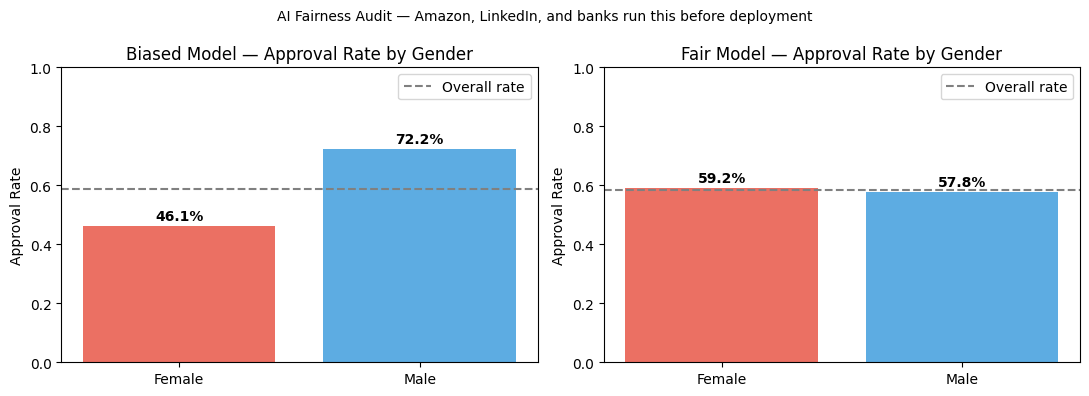


✅ Removing the gender feature reduces disparity significantly.
Real companies use Fairlearn (Microsoft) and IBM AI Fairness 360 for this analysis.


In [1]:
import numpy as np, matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

np.random.seed(42)

# ── Synthetic loan approval dataset with bias ──────────────────────────────
# Features: [income, credit_score, gender(0=F,1=M)]
n = 1000
income       = np.random.normal(50000, 15000, n)
credit_score = np.random.normal(650, 80, n)
gender       = np.random.randint(0, 2, n)  # 0=Female, 1=Male

# Introduce BIAS: same income/credit but men approved more often historically
# centered features so approvals are genuinely uncertain (~50%) instead of saturating at "approve everyone"
prob_approve = 1 / (1 + np.exp(-(
    0.00002*(income - 50000) + 0.02*(credit_score - 650) - 0.2 + 0.9*gender  # ← 0.9*gender = bias!
)))
approved = (np.random.rand(n) < prob_approve).astype(int)

X = np.column_stack([income, credit_score, gender])
X_biased  = X.copy()                        # includes gender
X_fair    = X[:, :2]                         # removes gender

# ── Train two models: biased and fair ──────────────────────────────────────
m_biased = LogisticRegression().fit(X_biased, approved)
m_fair   = LogisticRegression().fit(X_fair,   approved)

# ── Measure approval rates by gender ──────────────────────────────────────
for model_name, model, feats in [("Biased model", m_biased, X_biased),
                                   ("Fair model",   m_fair,   X_fair)]:
    pred = model.predict(feats)
    rate_f = pred[gender==0].mean()
    rate_m = pred[gender==1].mean()
    print(f"{model_name:15s} — Female approval: {rate_f:.1%}  Male approval: {rate_m:.1%}  "
          f"Disparity: {abs(rate_m-rate_f):.1%}")

# ── Visualise ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (name, model, feats) in zip(axes, [("Biased", m_biased, X_biased), ("Fair", m_fair, X_fair)]):
    pred = model.predict(feats)
    rates = [pred[gender==g].mean() for g in [0,1]]
    bars = ax.bar(['Female','Male'], rates, color=['#e74c3c','#3498db'], alpha=0.8)
    ax.set_ylim(0,1); ax.set_title(f"{name} Model — Approval Rate by Gender")
    ax.axhline(pred.mean(), color='gray', linestyle='--', label='Overall rate')
    ax.legend(); ax.set_ylabel("Approval Rate")
    for bar, rate in zip(bars, rates):
        ax.text(bar.get_x()+bar.get_width()/2, rate+0.02, f"{rate:.1%}", ha='center', fontweight='bold')
plt.suptitle("AI Fairness Audit — Amazon, LinkedIn, and banks run this before deployment", fontsize=10)
plt.tight_layout(); plt.show()

print("\n✅ Removing the gender feature reduces disparity significantly.")
print("Real companies use Fairlearn (Microsoft) and IBM AI Fairness 360 for this analysis.")

## 📝 Summary

In this notebook, you learned:
- The key ethical concerns in Generative AI: bias, misinformation, deepfakes, and copyright
- How fairness and transparency principles apply to generative models
- Real-world implications of synthetic content generation (GDPR, creative rights)
- Frameworks for responsible AI development and deployment

**Next steps:** Complete the ethics exercise and explore bias mitigation techniques in generative models.

## 📚 References & Further Reading

**Reports & Guidelines:**
- EU AI Act (2024) — [Official Text](https://eur-lex.europa.eu/legal-content/EN/TXT/?uri=CELEX:52021PC0206)
- UNESCO AI Ethics Recommendations — [Link](https://www.unesco.org/en/artificial-intelligence/recommendation-ethics)
- NIST AI Risk Management Framework — [Link](https://airc.nist.gov/RMF)

**Papers:**
- Bender et al. (2021) — [On the Dangers of Stochastic Parrots](https://dl.acm.org/doi/10.1145/3442188.3445922)
- Gebru et al. (2021) — [Datasheets for Datasets](https://arxiv.org/abs/1803.09010)

**State-of-the-Art:** The EU AI Act (2024) is the world's first binding AI regulation. OpenAI, Google, and Microsoft have dedicated AI safety teams.